In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from graphviz import Digraph

def trace(root):
    # build a set of all nodes and edges in the graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangle ('record') node for it
        dot.node(name = uid, label = '{ %s | data %.4f | grad %.4f }' % (n._label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is the result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect the operation to its inputs
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [3]:
class Value:

    def __init__(self, data, _children=(), _op='', _label=''):
        self.data = data
        self.grad = 0.0

        self._prev = set(_children)
        self._op = _op
        self._label = _label
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data

        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now."
        out = Value(self.data ** other, (self, ), f'**{other}')

        def _backward():
            self.grad += (other * self.data ** (other - 1)) * out.grad

        out._backward = _backward
        return out

    def exp(self):
        x = math.exp(self.data)
        out = Value(x, (self, ), 'exp')

        def _backward():
            self.grad += x * out.grad

        out._backward = _backward
        return out

    def tanh(self):
        e = math.exp(2 * self.data)
        t = (e - 1) / (e + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t ** 2) * out.grad

        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(node):
            if node in visited:
                return
            visited.add(node)
            for child in node._prev:
                build_topo(child)
            topo.append(node)

        build_topo(self)

        self.grad = 1.0
        for n in reversed(topo):
            n._backward()

    def __neg__(self):  # -self
        return -1 * self

    def __sub__(self, other):  # self + (-other)
        return self + -other

    def __truediv__(self, other):  # self / other
        return self * other ** -1

    def __radd__(self, other):  # other + self
        return self + other

    def __rsub__(self, other):  # other - self
        return -self + other

    def __rmul__(self, other):  # other * self
        return self * other


In [4]:
x1 = Value(2.0, _label='x1')
x2 = Value(0.0, _label='x2')
w1 = Value(-3.0, _label='w1')
w2 = Value(1.0, _label='w2')
b = Value(6.8813735870195432, _label='b')

x1w1 = x1 * w1; x1w1._label = 'x1w1'
x2w2 = x2 * w2; x2w2._label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2._label = 'x1w1+x2w2'

n = x1w1x2w2 + b; n._label = 'n'
o = n.tanh(); o._label = 'o'

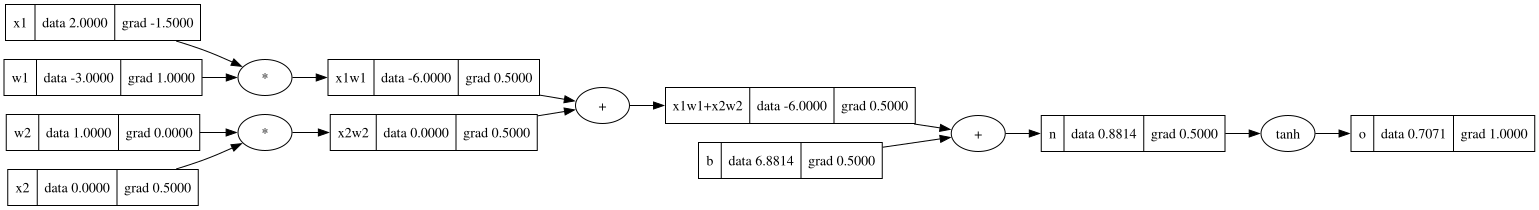

In [5]:
o.backward()
draw_dot(o)

In [55]:
import random


class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, xs):
        act = sum((wi * xi for wi, xi in zip(self.w, xs)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]


class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, xs):
        out = [neuron(xs) for neuron in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:

    def __init__(self, nin, outs):
        dims = [nin] + outs
        self.layers = [Layer(dims[i], dims[i + 1]) for i in range(len(outs))]

    def __call__(self, xs):
        for layer in self.layers:
            xs = layer(xs)
        return xs

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [56]:
n = MLP(3, [4, 4, 1])
len(n.parameters())

41

In [57]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

In [119]:
step = 10000
lr = 0.05

for i in range(step):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((ygt - yout) ** 2 for (ygt, yout) in zip(ys, ypred))

    # zero grad
    for p in n.parameters():
        p.grad = 0.0

    # backward pass
    loss.backward()

    # update parameters
    for p in n.parameters():
        p.data += -lr * p.grad

    # if i % 10 == 0:
        # print(f'step[{i}] {loss.data=}')


In [120]:
ypred

[Value(data=0.9978, grad=-0.0044),
 Value(data=-0.9968, grad=0.0063),
 Value(data=-0.9975, grad=0.0049),
 Value(data=0.9972, grad=-0.0056)]

In [121]:
loss.data

2.8659943695720778e-05